In [69]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance
import joblib
from scipy.ndimage import uniform_filter1d
from ovo_svm import OvO_SVM
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

In [70]:
# import easyocr

In [71]:
# model = joblib.load("hog_manual_svm_model.joblib")
# x = joblib.load("../visual/x_features_hog.joblib")
# y = joblib.load("../visual/y_labels_hog.joblib")
# le = LabelEncoder()
# y_encoded = le.fit_transform(y)
# train_x, test_x, train_y, test_y = train_test_split(x, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)
model = OvO_SVM().load("./models/from_scratch_SVM")
le = joblib.load("./models/from_scratch_SVM/OvO_SVM_label_encoder.joblib")


In [72]:
# label_encoder = joblib.load("label_encoder.joblib")

In [73]:
img = cv2.imread("./images/ocr.jpeg")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [74]:
# reader = easyocr.Reader(['en'])
# results = reader.readtext("./images/ocr.jpeg")

In [75]:
# for _, text, confidence in results:
#     print(text, confidence)

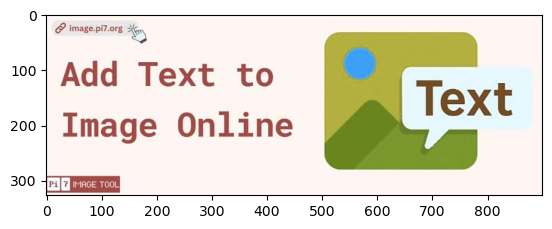

In [76]:
plt.imshow(img)

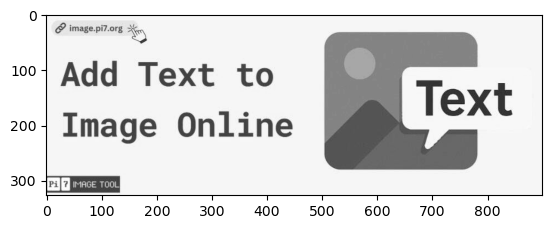

In [77]:
plt.imshow(gray, cmap='gray')

In [78]:
mser = cv2.MSER_create()
mser.setMinArea(150)

In [79]:
def merge_boxes(boxes, threshold=0.3):
    merged = []

    for box in boxes:
        x, y, w, h = box
        if w == 0 or h == 0:
            continue

        added = False

        for i, (mx, my, mw, mh) in enumerate(merged):

            # compute IoU
            xi1 = max(x, mx)
            yi1 = max(y, my)
            xi2 = min(x + w, mx + mw)
            yi2 = min(y + h, my + mh)

            inter = max(0, xi2 - xi1) * max(0, yi2 - yi1)

            area1 = w * h
            area2 = mw * mh
            union = area1 + area2 - inter

            iou = inter / (union + 1e-6)

            if iou > threshold:
                # merge boxes
                nx = min(x, mx)
                ny = min(y, my)
                nw = max(x + w, mx + mw) - nx
                nh = max(y + h, my + mh) - ny

                merged[i] = (nx, ny, nw, nh)
                added = True
                break

        if not added:
            merged.append((x, y, w, h))

    return merged

In [80]:
# def remove_holes(boxes, threshold=0.5):
#     filtered = []
#     for box in boxes:
#         x, y, w, h = box
#         roi = gray[y:y+h, x:x+w]
#         roi = cv2.threshold(roi, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)[1]
#         total_pixels = w * h
#         white_pixels = cv2.countNonZero(roi)
#         if white_pixels / total_pixels > threshold:
#             filtered.append(box)
#     return filtered

In [81]:
def filter_char_boxes(boxes, lower_bound=0.1, higher_bound=2.5):
    filtered = []
    for box in boxes:
        x, y, w, h = box
        if w == 0 or h == 0:
            continue
        aspect_ratio = w / (h + 1e-6)
        if lower_bound <= aspect_ratio <= higher_bound:
            filtered.append(box)
    return filtered

Number of regions: 696
Number of boxes: 696
Number of unique boxes: 36


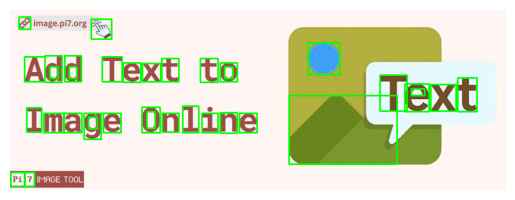

In [82]:
plt.axis('off')

regions, boxes = mser.detectRegions(gray)
unique_boxes = set(tuple(b) for b in boxes)
unique_boxes = [list(b) for b in unique_boxes]
unique_boxes = merge_boxes(unique_boxes, threshold=0.3)
unique_boxes = filter_char_boxes(unique_boxes, lower_bound=0.1, higher_bound=2.5)

print(f"Number of regions: {len(regions)}")
print(f"Number of boxes: {len(boxes)}")
print(f"Number of unique boxes: {len(unique_boxes)}")

img_copy = img.copy()
for i in range(len(unique_boxes)):
    x, y, w, h = unique_boxes[i]
    cv2.rectangle(img_copy, (x, y), (x + w, y + h), (0, 255, 0), 2)
plt.imshow(img_copy)
plt.show()
box_0 = unique_boxes[0]
char_0 = gray[box_0[1]:box_0[1]+box_0[3], box_0[0]:box_0[0]+box_0[2]]


In [83]:
def merge_char_words(boxes, x_thresh=20, y_thresh=10):
    used = [False] * len(boxes)
    words = []

    for i in range(len(boxes)):
        if used[i]:
            continue

        word = [boxes[i]]
        used[i] = True

        changed = True

        while changed:
            changed = False

            for j in range(len(boxes)):
                if used[j]:
                    continue

                x1, y1, w1, h1 = boxes[j]

                for wx, wy, ww, wh in word:
                    # check same line
                    if abs(wy - y1) < y_thresh:
                        # check horizontal gap
                        if abs((wx + ww) - x1) < x_thresh or abs((x1 + w1) - wx) < x_thresh:
                            word.append(boxes[j])
                            used[j] = True
                            changed = True
                            break

        words.append(sorted(word, key=lambda b: b[0]))

    return words

In [84]:
def get_word_boxes(words):
    word_boxes = []

    for word in words:
        x_min = min(x for x, y, w, h in word)
        y_min = min(y for x, y, w, h in word)
        x_max = max(x + w for x, y, w, h in word)
        y_max = max(y + h for x, y, w, h in word)

        word_boxes.append((x_min, y_min, x_max - x_min, y_max - y_min))

    return word_boxes

In [85]:
words = merge_char_words(unique_boxes, x_thresh=10, y_thresh=20)
print(f"Number of words: {len(words)}")

Number of words: 16


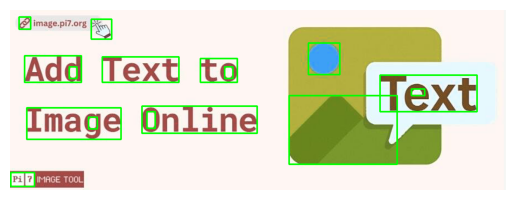

16


In [86]:
word_boxes = get_word_boxes(words)

img_copy = img.copy()

for (x, y, w, h) in word_boxes:
    cv2.rectangle(
        img_copy,
        (x, y),
        (x + w, y + h),
        (0, 255, 0),
        2
    )

plt.imshow(img_copy)
plt.axis("off")
plt.show()
print(len(words))

In [48]:
IMG_SIZE = 128
def calc_gradients(image):
    Gx = np.array([[-1, 0, 1]], dtype=np.float32)
    Gy = np.array([[-1], [0], [1]], dtype=np.float32)

    image = image.astype(np.float32)

    gx = cv2.filter2D(image, -1, Gx)
    gy = cv2.filter2D(image, -1, Gy)
    
    gradients_magnitude = np.sqrt(gx**2 + gy**2)
    gradients_orientation = (np.arctan2(gy, gx) * 180 / np.pi) % 180

    return gradients_magnitude, gradients_orientation


def HoG(orientations, magnitudes, cell_size=16, num_bins=9, block_size=2):
    bin_size = 180 / num_bins

    h, w = orientations.shape
    cells_y = h // cell_size
    cells_x = w // cell_size

    histograms = np.zeros((cells_y, cells_x, num_bins), dtype=np.float32)
    
    for cy in range(cells_y):
        for cx in range(cells_x):
            y0 = cy * cell_size
            x0 = cx * cell_size

            for y in range(cell_size):
                for x in range(cell_size):
                    angle = orientations[y0 + y, x0 + x]
                    mag = magnitudes[y0 + y, x0 + x]

                    bin_idx = int(angle / bin_size) % num_bins
                    histograms[cy, cx, bin_idx] += mag
                    
    features = []

    for y in range(cells_y - 1):
        for x in range(cells_x - 1):
            block = histograms[y:y+block_size, x:x+block_size].flatten()

            norm = np.linalg.norm(block)
            block = block / (norm + 1e-6)

            features.extend(block)

    return np.array(features, dtype=np.float32)

In [49]:
def predict(features, model=model, le=le):
    features = np.asarray(features)

    if features.ndim == 1:
        features = features.reshape(1, -1)

    model.classes = np.asarray(model.classes)
    predicted_label = model.predict(features)
    props = model.predict_proba(features)
    confidence = model.confidence(features)
    return predicted_label, confidence, props


In [50]:
def sort_boxes_reading_order(boxes, y_thresh=10):
    # first sort by y
    boxes = sorted(boxes, key=lambda b: b[1])

    lines = []

    for box in boxes:
        x, y, w, h = box
        placed = False

        for line in lines:
            if abs(line[0][1] - y) < y_thresh:
                line.append(box)
                placed = True
                break

        if not placed:
            lines.append([box])

    # sort each line by x
    for line in lines:
        line.sort(key=lambda b: b[0])

    # flatten
    return [b for line in lines for b in line]

In [53]:
unique_boxes = sort_boxes_reading_order(unique_boxes, y_thresh=10)
words = merge_char_words(unique_boxes, x_thresh=20, y_thresh=30)
print(f"Number of words: {len(words)}")
text = ""
for word in words:
    for box in word:
        x, y, w, h = box
        # print(f"width: {w}, height: {h}")
        # print(f"Box {i}: x={x}, y={y}")
        char_img = gray[y:y+h, x:x+w]
        # plt.imshow(char_img, cmap='gray')
        # plt.show()
        
        ## border
        padded_char_img = cv2.copyMakeBorder(char_img, 5, 5, 5, 5, cv2.BORDER_CONSTANT, value=255)
        ## blur
        blurred_char_img = cv2.GaussianBlur(padded_char_img, (5, 5), 0)

        ## binarize
        binarized_char_img = cv2.adaptiveThreshold(
            blurred_char_img,
            255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY_INV,
            11,
            2
        )
        
        ## resize
        resized_char_img = cv2.resize(
            binarized_char_img,
            (128, 128),
            interpolation=cv2.INTER_CUBIC
        )

        ## erode and dilate
        eroded = cv2.erode(resized_char_img, np.ones((5, 5), np.uint8), iterations=2)
        dilated = cv2.dilate(eroded, np.ones((3, 3), np.uint8), iterations=5)

        ## normalized
        normalized_char_img = dilated.astype(np.float32) / 255.0

        magnitudes, orientations = calc_gradients(normalized_char_img)
        features = HoG(orientations, magnitudes)
        # predicted_label, scores = predict(features)
        predicted_label, confidence, props = predict(features)
        top3 = sorted(props[0], reverse=True)[:3]
        # print(top3)
        # print(top3[0]/top3[1])
        # print("Predicted label for test image:", le.inverse_transform(predicted_label)[0])
        # plt.imshow(normalized_char_img, cmap='gray')
        # plt.show()
        text += le.inverse_transform(predicted_label)[0]
        text += " "
    # text += " "

Number of words: 11


In [54]:
toLower = text.lower()
print(toLower)

a m n h u a u d u d u t e a x t t o u j t e n x t t m a a g n e e o n n l l n e e e n 
